In [1]:
%pip install -r ../requirements.txt -q
import warnings
warnings.filterwarnings('ignore')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.2.0 requires pandas<3,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
otter-grader 6.1.3 requires wrapt<2.0.0,>=1.16.0, but you have wrapt 2.1.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from eep153_tools.sheets import read_sheets



In [3]:
NG_URL= "https://docs.google.com/spreadsheets/d/1rbWPdn_Rt3MRoFb_wkomHBcNVmM-3F3lNwCpxP5W_3g/edit?gid=1354121303#gid=1354121303" 

# Deliverable A : Estimating the Nigerian Demand System

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FE_Sheets = ["Food Expenditures (2010Q3)", "Food Expenditures (2011Q1)", "Food Expenditures (2012Q3)", "Food Expenditures (2013Q1)", "Food Expenditures (2015Q3)", "Food Expenditures (2016Q1)"]

FP_Sheets = ["Food Prices (2010Q3)", "Food Prices (2011Q1)", "Food Prices (2012Q3)", "Food Prices (2013Q1)", "Food Prices (2015Q3)", "Food Prices (2016Q1)"]

def prepare_data(NG_URL, FE_Sheet, household_sheet="Household Characteristics"): 
    x = read_sheets(NG_URL, sheet = FE_Sheet)
    d = read_sheets(NG_URL ,sheet = household_sheet)

    # data cleaning to ensure key columns match exactly
    for df in [x, d]:
        df['i'] = pd.to_numeric(df['i'], errors='coerce')
        df['t'] = df['t'].astype(str).str.strip()
        df['m'] = (
            df['m']
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )


    d.columns.name = 'k'
    # remove duplicate column names, keep first occurrence
    d = d.loc[:, ~d.columns.duplicated()]

    # collapse duplicate household rows
    d = d.groupby(['i','t','m'], as_index=False).first()

    # Data comes in long format; pivot to wide (one column per food)
    x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
    x = x.replace(0.0001,np.nan) # Replace zeros with missing
    
    y = x

    d.set_index(['i','t','m'],inplace=True)

    # NaN in demographic columns means zero people in that category
    d = d.fillna(0)

    return y, d


In [5]:
y, d = prepare_data(NG_URL, "Food Expenditures (2016Q1)")

In [6]:
log_y = np.log(y)

In [7]:
log_y = log_y.stack().dropna()

d = d.stack().dropna()

In [8]:
from cfe import Regression as rgsn

result = rgsn(y=log_y,d=d)

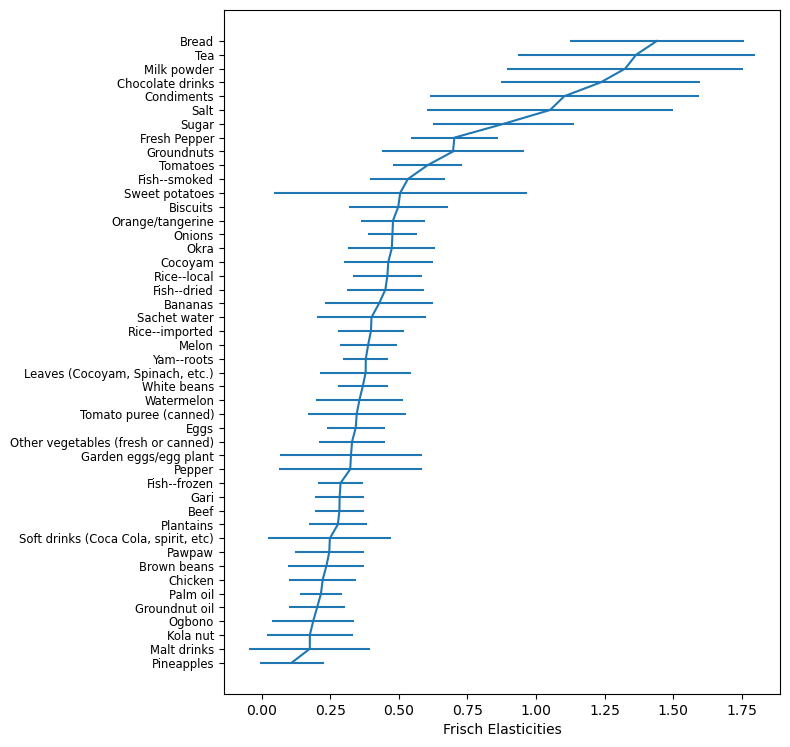

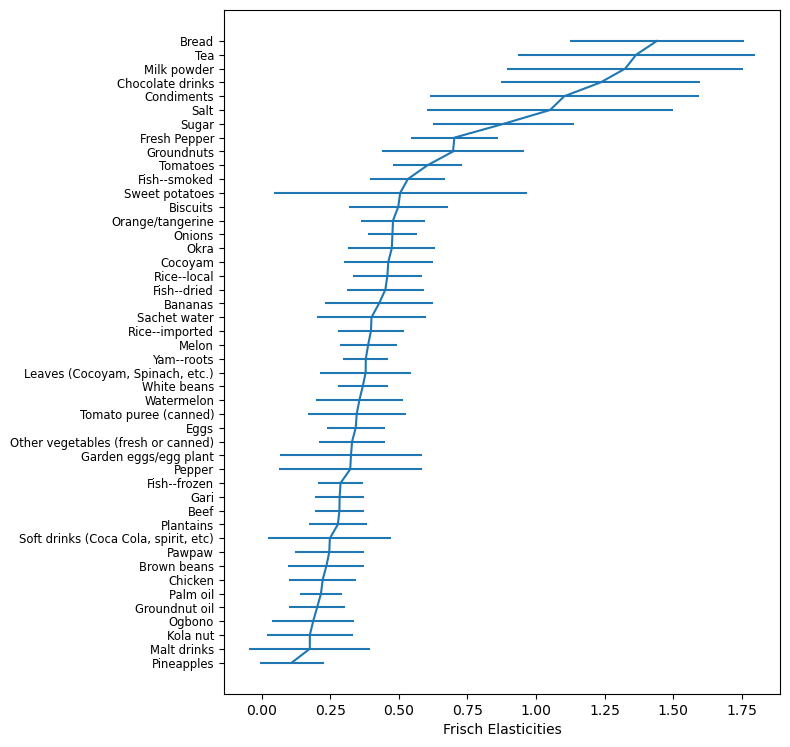

In [9]:
result.graph_beta()

## What do the beta values tell us?

Larger beta values correspond to foods with larger Frish Elasticities. The most extreme examples of this, on both sides would be bread and pineapples.

As household income begins to rise, spending on foods that exhibit high income elasticity would also rise, such as bread and tea.

On the other end, foods that are relatively income inelastic, such as pineapples and malt drinks, don't react as much to any changes in household income. These are essentially staples in the diet.

In [41]:
result.gamma

k,Female 00-03,Female 04-08,Female 09-13,Female 14-18,Female 19-30,Female 31-50,Female 51+,Female NA,Male 00-03,Male 04-08,Male 09-13,Male 14-18,Male 19-30,Male 31-50,Male 51+,Male NA,log HSize,Constant
j,,,,,,,,,,,,,,,,,,
Bananas,-0.073013,0.070019,0.096545,0.108353,0.150393,0.165893,0.150281,0.024814,0.046503,0.034176,0.083921,0.113344,0.053774,0.108180,0.085294,-0.017933,0.047383,5.215043
Beef,-0.004548,0.005960,-0.018177,0.003144,0.081884,0.020772,0.008627,-0.022642,-0.023783,0.044092,-0.007670,0.034180,0.047685,0.109358,0.146129,-0.042846,0.190226,6.759567
Biscuits,-0.001854,0.055226,-0.021374,0.025799,-0.015120,0.051166,-0.135300,-0.010417,0.108349,-0.043725,-0.052534,-0.020993,0.024836,0.108465,0.053022,-0.017397,0.340834,3.994985
Bread,-0.108352,-0.148544,-0.186654,-0.056737,-0.017390,-0.023116,0.032171,-0.093828,-0.048818,-0.011707,-0.048302,0.003657,-0.196795,-0.145219,-0.046244,-0.115196,0.624720,5.507083
Brown beans,-0.009496,0.036456,0.040938,-0.045043,0.062893,0.083456,0.137873,-0.030332,-0.058265,0.108094,0.029861,-0.029247,0.057962,0.116353,-0.011903,-0.029039,0.361071,5.874225
Chicken,0.029744,0.111941,0.057465,-0.003257,0.095947,0.139365,0.078267,0.017335,0.007504,0.051729,0.048046,0.150360,0.074479,-0.011283,0.185726,0.021229,-0.227989,7.152837
Chocolate drinks,-0.011696,-0.018085,-0.007632,0.177774,0.047536,0.097233,0.092393,-0.003222,0.058936,0.037790,-0.098449,0.027890,0.127923,0.131830,0.098284,-0.057528,0.362924,5.347818
Cocoyam,0.017506,-0.009624,0.022849,-0.000189,0.098178,0.091565,0.054931,0.015511,-0.003198,-0.059145,0.086451,-0.029486,0.044738,0.141889,0.133776,-0.029391,0.117694,5.365803
Condiments,0.089226,0.108974,0.175919,-0.038493,0.134788,0.356103,0.227464,-0.075642,0.052687,-0.021934,0.095180,0.117202,0.237487,0.157345,-0.011707,-0.071871,0.353454,4.107178


## What does gamma tell us?

These values essentially tell us how demand across different foods react with household composition.

So for example, foods like beef tend to not be purchases as much when the household composition leans towards a younger demographic, which makes sense because toddlers don't eat beef. In contrast, if the household composition is on the older end, we can expect a larger share of the diet to be beef.

In [10]:
FCT = pd.read_csv("../data/NigerianFCT.csv")

In [11]:
FCT = FCT.rename(columns = {'Unnamed: 0' : 'j'})

FCT = FCT.set_index('j')

FCT = FCT.apply(lambda x: pd.to_numeric(x,errors='coerce'))

FCT = FCT.fillna(0.001)

FCT = FCT.replace(0, 0.001)

# Deliverable B : Nutritional Content of Foods in the Nigerian Diet

In [40]:
FCT.head()

,Alanine,"Alcohol, ethyl",Amino acids,Arginine,Ash,Aspartic acid,Betaine,Caffeine,"Calcium, Ca","Carbohydrate, by difference",...,Vitamin D2 (ergocalciferol),Vitamin D3 (cholecalciferol),Vitamin E (alpha-tocopherol),"Vitamin E, added",Vitamin K (Dihydrophylloquinone),Vitamin K (Menaquinone-4),Vitamin K (phylloquinone),Vitamins and Other Components,Water,"Zinc, Zn"
j,,,,,,,,,,,,,,,,,,,,,
Malt drinks,0.001,0.001,0.001,0.001,1.900,0.001,0.001,37.000,60.0,86.94,...,0.001,0.001,0.170,0.001,0.001,0.001,2.500,0.001,1.300,0.800
"Soft drinks (Coca Cola, spirit, etc)",0.001,0.001,0.001,0.001,0.001,0.001,0.001,9.000,1.0,10.40,...,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,89.400,0.090
Plantains,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,9.0,63.80,...,0.001,0.001,5.040,0.001,0.001,0.001,28.600,0.001,2.090,0.370
Yam--roots,0.063,0.001,0.001,0.127,0.820,0.155,0.001,0.001,17.0,27.88,...,0.001,0.001,0.350,0.001,0.001,0.001,2.300,0.001,69.600,0.240
Milk powder,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,1292.0,54.17,...,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001


In [12]:
RDI = pd.read_csv('../data/NigerianRDI.csv')

RDI = RDI.set_index('n')
RDI.columns.name = 'k'


In [13]:
p = read_sheets(NG_URL, sheet = "Food Prices (2016Q1)")

In [14]:
pbar = p.groupby('j')['Price'].mean()
pbar = pbar[result.beta.index] # Only use prices for goods we can estimate

In [15]:
xhat = result.predicted_expenditures()

# Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()

# Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

In [16]:
qhat = (xhat.unstack('j')/pbar).dropna(how='all')

# Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

qhat

,,j,Bananas,Beef,Biscuits,Bread,Brown beans,Chicken,Chocolate drinks,Cocoyam,Condiments,Eggs,...,Salt,"Soft drinks (Coca Cola, spirit, etc)",Sugar,Sweet potatoes,Tea,Tomato puree (canned),Tomatoes,Watermelon,White beans,Yam--roots
i,t,m,,,,,,,,,,,,,,,,,,,,,
10001,2016Q1,south east,1.115353,0.985875,0.175078,1.252425,1.356521,1.430572,0.135295,1.441031,0.184704,0.137128,...,0.168322,1.038487,0.115192,1.837988,0.027959,0.223161,1.135049,4.834810,1.296786,10.758984
10002,2016Q1,south east,1.331909,1.208527,0.229007,3.733499,1.350642,1.722139,0.318005,2.068230,0.360398,0.158007,...,0.412763,1.084841,0.221322,3.304496,0.087541,0.235269,1.726713,5.940646,1.672820,15.378039
10003,2016Q1,south east,1.118062,1.026274,0.126578,1.129347,1.075674,1.395224,0.127088,1.503929,0.168574,0.116121,...,0.158253,1.097295,0.122061,2.469352,0.041353,0.209090,1.014862,4.810767,1.358221,11.437190
10004,2016Q1,south east,1.078760,0.970528,0.109292,1.592027,1.096141,1.388063,0.131934,1.461382,0.153226,0.097985,...,0.159837,0.998702,0.111994,2.812724,0.043796,0.187149,1.094369,5.287222,1.244191,11.718531
10005,2016Q1,south east,1.450775,1.055790,0.164304,1.312352,1.416582,1.277544,0.158789,1.711149,0.336489,0.155609,...,0.231416,1.228779,0.181754,2.225617,0.085083,0.163653,1.219287,5.660818,1.597103,13.385565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370036,2016Q1,north central,0.930348,1.000908,0.145251,0.588576,1.509571,1.222790,0.082811,1.486383,0.130756,0.182843,...,0.162007,1.152854,0.206812,1.313890,0.051965,0.272673,0.759420,5.349193,1.775075,14.254794
370037,2016Q1,north central,0.359876,0.486750,0.041617,0.031328,0.849293,0.825129,0.005373,0.539710,0.014311,0.075280,...,0.015986,0.679790,0.027195,0.501567,0.003955,0.111120,0.214441,2.757805,0.785947,6.090452
370038,2016Q1,north central,0.421751,0.594080,0.055121,0.091040,1.012993,0.882402,0.013922,0.629720,0.022794,0.092058,...,0.025699,0.719588,0.043142,0.674491,0.012837,0.125185,0.321005,3.460177,0.917241,7.078883


In [17]:
def my_prices(p0, p=pbar, j=None):
    p = p.copy()
    if j is not None:
        p.loc[j] = p0
    return p

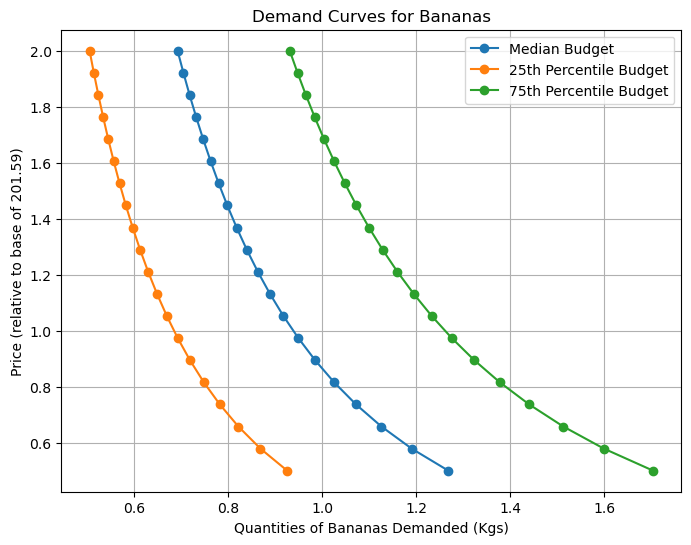

In [18]:

%matplotlib inline

plt.close('all')          # optional: closes old figures
plt.figure(figsize=(8,6)) # start a new clean figure

use = 'Bananas'   # Good we want demand curve for
scale = np.linspace(0.5, 2, 20)

plt.close('all')
plt.figure(figsize=(8,6))

# Median budget household
median_demands = [
    result.demands(
        xref,
        my_prices(pbar[use] * s, pbar, j=use)
    )[use]
    for s in scale
]

# 25th percentile household
q25_demands = [
    result.demands(
        xbar.quantile(0.25),
        my_prices(pbar[use] * s, pbar, j=use)
    )[use]
    for s in scale
]

# 75th percentile household
q75_demands = [
    result.demands(
        xbar.quantile(0.75),
        my_prices(pbar[use] * s, pbar, j=use)
    )[use]
    for s in scale
]

# Plot all three demand curves
plt.plot(median_demands, scale, marker='o', label='Median Budget')
plt.plot(q25_demands, scale, marker='o', label='25th Percentile Budget')
plt.plot(q75_demands, scale, marker='o', label='75th Percentile Budget')

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded (Kgs)")
plt.title(f"Demand Curves for {use}")
plt.legend()
plt.grid(True)

plt.show()


We can see a general trend across food demand, as we household get larger budgets to work with, they can start demanding more quantities of foods.

Text(0.5, 1.0, 'Engel Curves')

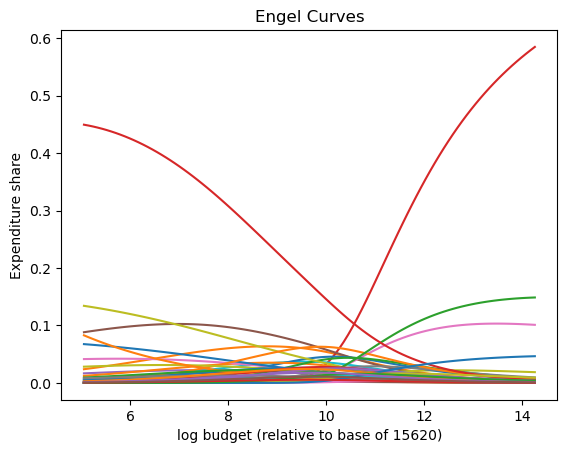

In [19]:
fig,ax = plt.subplots()

scale = np.geomspace(0.01,100,100)
ax.plot(np.log(scale*xref),[result.expenditures(s*xref,pbar)/(s*xref) for s in scale])
ax.set_xlabel(f'log budget (relative to base of {xref:.0f})')
ax.set_ylabel(f'Expenditure share')
ax.set_title('Engel Curves')

In [20]:
# Create a new FCT and vector of consumption that only share rows in common:
# Convert FCT index to string so it can match 'Bananas'
fct0,c0 = FCT.align(qhat.T,axis=0,join='inner')
print(fct0.index)

Index(['Malt drinks', 'Soft drinks (Coca Cola, spirit, etc)', 'Plantains',
       'Yam--roots', 'Milk powder', 'Chicken', 'Condiments', 'Tea',
       'Sachet water', 'Palm oil', 'Chocolate drinks', 'Tomato puree (canned)',
       'Fish--frozen', 'Eggs', 'Bread', 'Groundnut oil', 'Beef', 'Fish--dried',
       'Rice--local', 'Sweet potatoes', 'Fish--smoked', 'Gari', 'Sugar',
       'Onions', 'Groundnuts', 'White beans', 'Pepper', 'Bananas', 'Tomatoes',
       'Other vegetables (fresh or canned)', 'Rice--imported', 'Brown beans',
       'Okra', 'Leaves (Cocoyam, Spinach, etc.)'],
      dtype='str', name='j')


In [21]:
# The @ operator means matrix multiply
N = fct0.T@c0

N  #NB: Uganda quantities are for previous 7 days

i,10001,10002,10003,10004,10005,10008,10009,10010,10011,10012,...,370031,370032,370033,370034,370035,370036,370037,370038,370039,370040
t,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,...,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1
m,south east,south east,south east,south east,south east,south east,south east,south east,south east,south east,...,north central,north central,north central,north central,north central,north central,north central,north central,north central,north central
Alanine,7.398197,9.408397,7.837116,7.249375,9.035955,8.760194,6.691185,7.252287,9.082832,9.474388,...,5.858937,12.360987,3.780334,4.147524,5.567286,6.986555,2.765722,3.306272,6.603123,7.191723
"Alcohol, ethyl",0.046758,0.066717,0.049402,0.051019,0.059455,0.050952,0.043380,0.047376,0.055237,0.061002,...,0.041712,0.081948,0.032331,0.036286,0.047382,0.055399,0.025155,0.029076,0.047185,0.058825
Amino acids,0.046758,0.066717,0.049402,0.051019,0.059455,0.050952,0.043380,0.047376,0.055237,0.061002,...,0.041712,0.081948,0.032331,0.036286,0.047382,0.055399,0.025155,0.029076,0.047185,0.058825
Arginine,8.613311,10.946186,9.186356,8.386775,10.538800,10.354307,7.791244,8.287102,10.452390,11.369499,...,7.562730,15.680482,4.754874,5.198957,6.795191,8.620098,3.455147,4.097350,8.236169,9.045040
Ash,30.328757,39.770895,32.260450,30.951969,36.437202,34.250463,26.383372,31.011085,37.059404,35.604819,...,26.268190,48.525985,18.051629,20.827240,26.608754,32.470264,13.733193,16.055839,31.690105,32.770915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vitamin K (Menaquinone-4),0.046758,0.066717,0.049402,0.051019,0.059455,0.050952,0.043380,0.047376,0.055237,0.061002,...,0.041712,0.081948,0.032331,0.036286,0.047382,0.055399,0.025155,0.029076,0.047185,0.058825
Vitamin K (phylloquinone),89.156107,110.492220,93.619944,88.927473,111.726300,98.281642,77.767147,83.871326,105.725945,118.173719,...,101.966168,168.318665,64.828331,80.425931,86.252786,99.560410,51.820249,61.202129,110.056006,117.917655


## Deliverable A : Nutrient System

In [22]:
def nutrient_demand(x,p,r=result,fct=FCT):
    c = result.demands(x,p)
    fct0,c0 = fct.align(c,axis=0,join='inner')
    N = fct0.T@c0


    # Drop duplicate nutrient rows (keeps first).  If your FCT has
    # duplicates this silently discards data; worth checking with
    # fct.index[fct.index.duplicated()] to see what's being dropped.
    N = N.loc[~N.index.duplicated()]

    return N

Text(0, 0.5, 'log nutrient')

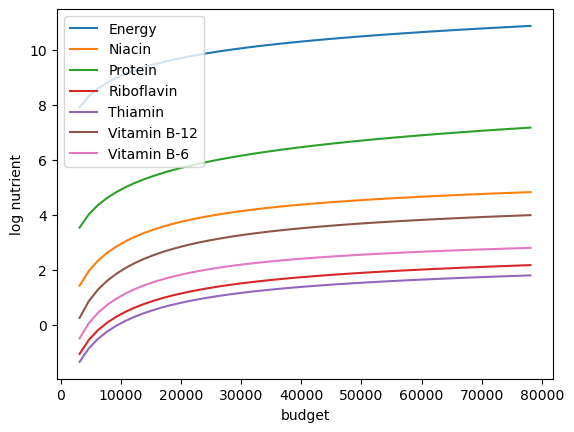

In [54]:
X = np.linspace(xref/5,xref*5,50)

UseNutrients = ['Energy', 'Niacin', 'Protein', 'Riboflavin', 'Thiamin', 'Vitamin B-12', 'Vitamin B-6']

df = pd.concat({myx:np.log(nutrient_demand(myx,pbar))[UseNutrients] for myx in X},axis=1).T
ax = df.plot()

ax.set_xlabel('budget')
ax.set_ylabel('log nutrient')

As expected, when household budgets increase, so do the intake of these nutrients as households can demand more food.

In [24]:
def ceteris_paribus_price(j,p0,p=pbar):
    """
    Return price vector with the price of good j set to p0,
    holding all other prices fixed at p.
    """
    p = p.copy()
    p.loc[j] = p0
    return p

Text(0, 0.5, 'log nutrient')

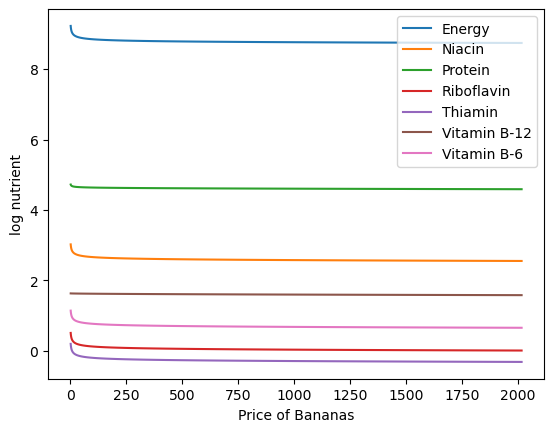

In [45]:
USE_GOOD = 'Bananas'

scale = np.geomspace(.01,10,50)

ndf = pd.DataFrame({s*pbar[USE_GOOD]:np.log(nutrient_demand(xref/2,ceteris_paribus_price(USE_GOOD,pbar[USE_GOOD]*s)))[UseNutrients] for s in scale}).T

ax = ndf.plot()

ax.set_xlabel(f'Price of {USE_GOOD}')
ax.set_ylabel('log nutrient')

Text(0, 0.5, 'log nutrient')

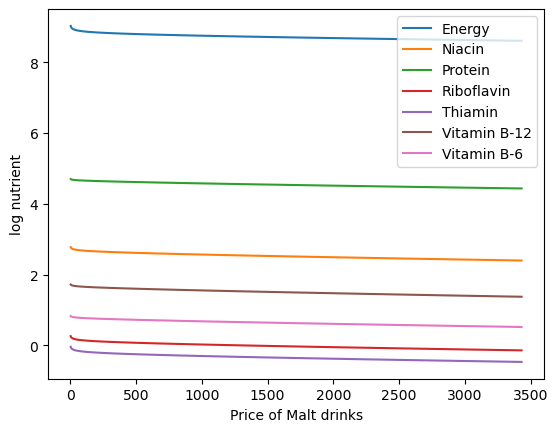

In [47]:
USE_GOOD = 'Malt drinks'

scale = np.geomspace(.01,10,50)

ndf = pd.DataFrame({s*pbar[USE_GOOD]:np.log(nutrient_demand(xref/2,ceteris_paribus_price(USE_GOOD,pbar[USE_GOOD]*s)))[UseNutrients] for s in scale}).T

ax = ndf.plot()

ax.set_xlabel(f'Price of {USE_GOOD}')
ax.set_ylabel('log nutrient')

Here, we look at 2 examples of the log nutrient intakes as a function of the price of different foods. With a more elastic good such as bananas, we see a sharper descent in nutrient intakes as price increases, whereas with an inelastic food such as malt drinks, we see a smoother descent in nutrition with an increase in price.

In [26]:
# In first round, averaged over households and villages
mapping = {
    'Females 00-03': 'Female 00-03',
    'Males 00-03':   'Male 00-03',
    'Females 04-08': 'Female 04-08',
    'Males 04-08':   'Male 04-08',
    'Females 09-13': 'Female 09-13',
    'Males 09-13':   'Male 09-13',
    'Females 14-18': 'Female 14-18',
    'Males 14-18':   'Male 14-18',
    'Females 19-30': 'Female 19-30',
    'Males 19-30':   'Male 19-30',
    'Females 31-50': 'Female 31-50',
    'Males 31-50':   'Male 31-50',
    'Females 51-99': 'Female 51+',
    'Males 51-99':   'Male 51+'
}

RDI = RDI.rename(columns=mapping)

dbar = result.d[RDI.columns].mean()

In [27]:
dbar

k
Female 00-03    0.246937
Male 00-03      0.265316
Female 04-08    0.416824
Male 04-08      0.439208
Female 09-13    0.420358
Male 09-13      0.465834
Female 14-18    0.303723
Male 14-18      0.388077
Female 19-30    0.509661
Male 19-30      0.477851
Female 31-50    0.622997
Male 31-50      0.429076
Female 51+      0.368049
Male 51+        0.396560
dtype: float64

In [28]:
# This matrix product gives minimum nutrient requirements for
# the average household
hh_rdi = RDI@dbar

hh_rdi

n
Energy          10152.403393
Protein           229.233506
Fiber             142.133648
Folate           1912.299717
Calcium          6143.803016
Carbohydrate      747.561263
Iron               61.820452
Magnesium        1646.439680
Niacin             72.883129
Phosphorus       4599.078699
Potassium       25208.718190
Riboflavin          5.720853
Thiamin             5.551697
Vitamin A        3813.312912
Vitamin B-12       11.473798
Vitamin B-6         6.402592
Vitamin C         347.677898
Vitamin E          71.253770
Vitamin K         458.987983
Zinc               46.252828
dtype: float64

In [29]:
def nutrient_adequacy_ratio(x,p,d,rdi=RDI,days=7):
    hh_rdi = rdi.replace('',0.01)@d*days

    return nutrient_demand(x,p)/hh_rdi

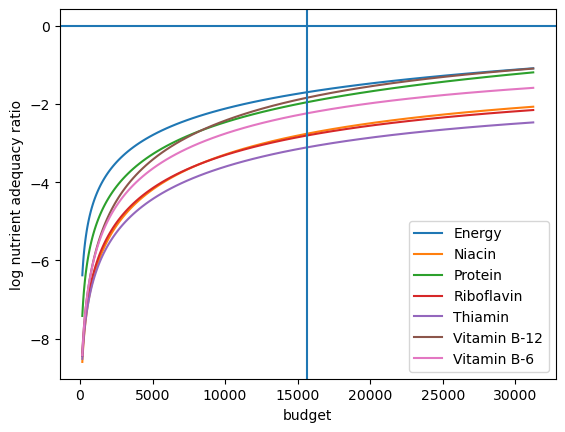

In [30]:
X = np.geomspace(.01*xref,2*xref,100)

fig,ax = plt.subplots()

pd.DataFrame({x:np.log(nutrient_adequacy_ratio(x,pbar,dbar))[UseNutrients] for x in X}).T.plot(ax=ax)

ax.legend(UseNutrients)
ax.set_xlabel('budget')
ax.set_ylabel('log nutrient adequacy ratio')
ax.axhline(0)
ax.axvline(xref)

Across all of these nutrients, nigerian households across most quantiles of budgets don't seem to be hitting essential nutrition goals such as energy and protein.

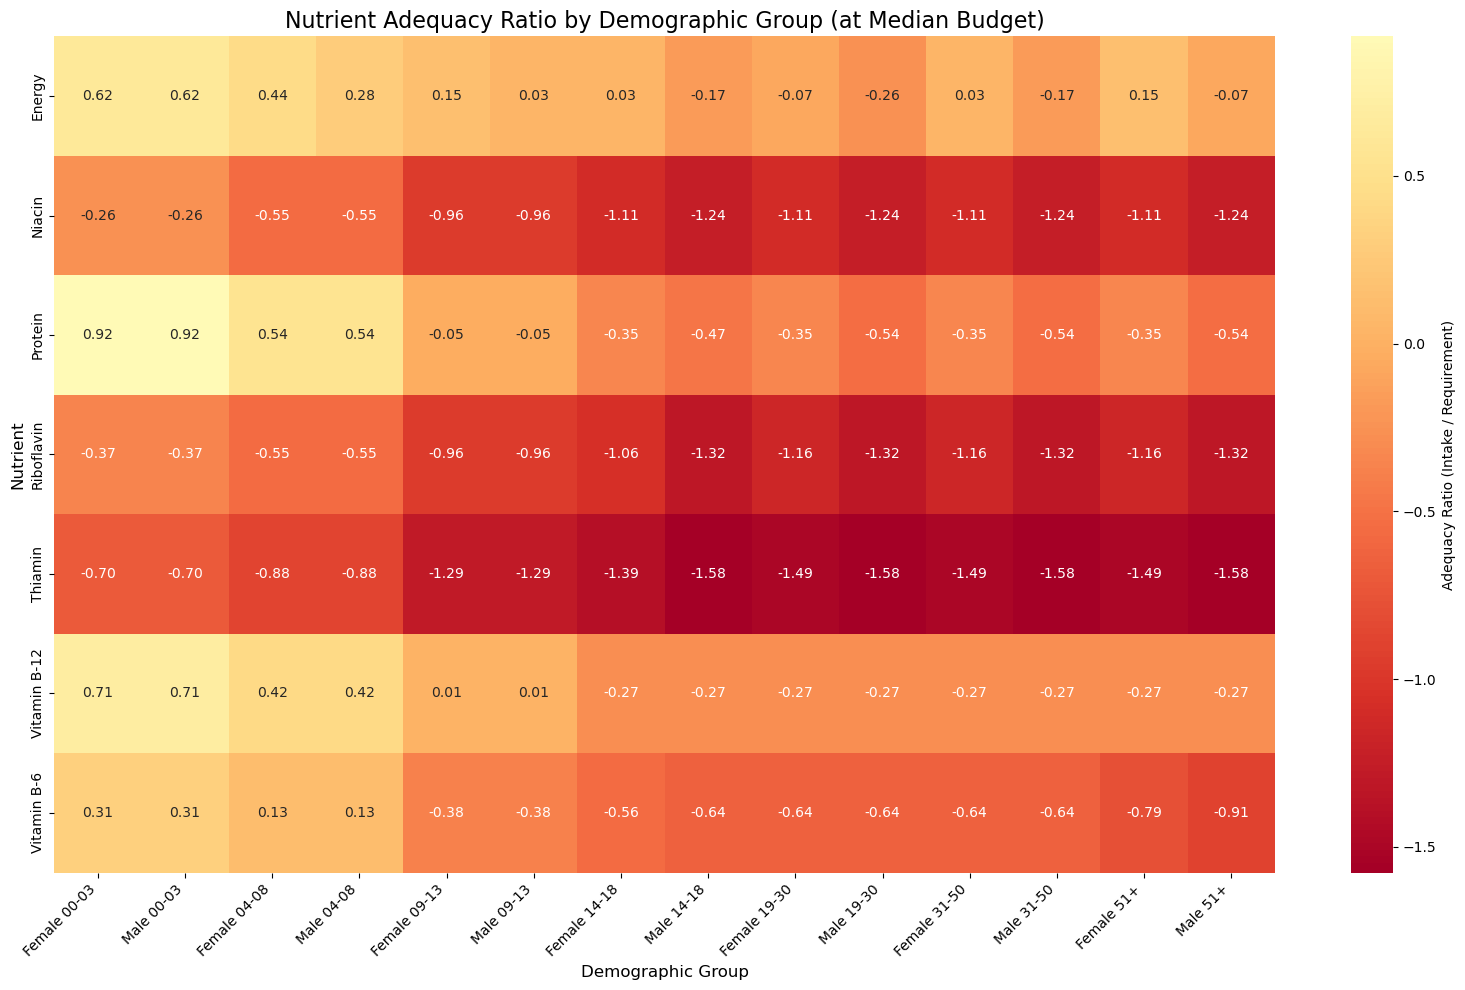

In [61]:
import seaborn as sns

demographics = RDI.columns

adequacy_ratios = {}

for group in demographics:
    # Create a demographic vector 'd' for a single person of this group
    d_single = pd.Series(0, index=RDI.columns)
    d_single[group] = 1
    
    # This automatically handles the RDI matrix product and the 7-day scale
    ratios = np.log(nutrient_adequacy_ratio(xref, pbar, d_single))
    
    # Filter for the nutrients of interest
    adequacy_ratios[group] = ratios.reindex(UseNutrients)

# 3. Construct the DataFrame for the heatmap
# Rows = Nutrients, Columns = Demographic Groups
adequacy_df = pd.DataFrame(adequacy_ratios)

# 4. Generate the Heatmap
plt.figure(figsize=(16, 10))

sns.heatmap(adequacy_df, 
            annot=True, 
            fmt=".2f", 
            cmap='RdYlGn', 
            center=1,
            cbar_kws={'label': 'Adequacy Ratio (Intake / Requirement)'})

plt.title('Nutrient Adequacy Ratio by Demographic Group (at Median Budget)', fontsize=16)
plt.xlabel('Demographic Group', fontsize=12)
plt.ylabel('Nutrient', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

Text(0.5, 0, 'log nutrient adequacy ratio')

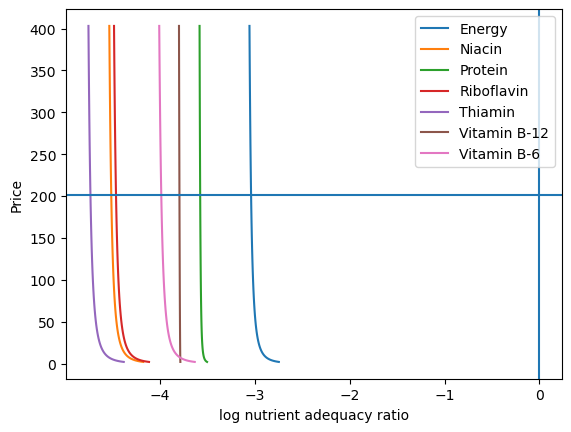

In [32]:
scale = np.geomspace(.01,2,50)

ndf = pd.DataFrame({s*pbar[USE_GOOD]:np.log(nutrient_adequacy_ratio(xref/4,ceteris_paribus_price(USE_GOOD,pbar[USE_GOOD]*s),dbar))[UseNutrients] for s in scale}).T

fig,ax = plt.subplots()
ax.plot(ndf,ndf.index)
ax.axhline(pbar[USE_GOOD])
ax.axvline(0)
ax.legend(UseNutrients)

ax.set_ylabel('Price')
ax.set_xlabel('log nutrient adequacy ratio')

# Deliverable B: Nutritional Adequacy, & Deliverable A : Nutritional Challenges and Policy Goals

In [33]:
adequacy = N.div(hh_rdi, axis=0)

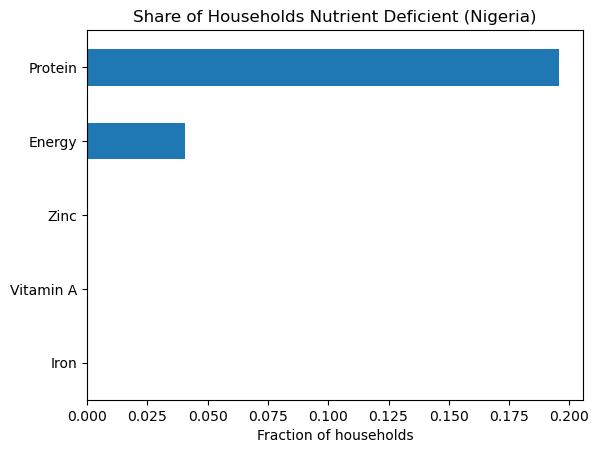

In [34]:
nutrients = ['Energy', 'Protein', 'Vitamin A', 'Iron', 'Zinc']

deficiency_rates = (adequacy.loc[nutrients] < 1).mean(axis=1)

deficiency_rates.sort_values().plot(kind='barh')
plt.title("Share of Households Nutrient Deficient (Nigeria)")
plt.xlabel("Fraction of households")
plt.show()

This graph shows the fraction of households that fail to meet recommended nutrient intake levels. We see that protein deficiency is the most widespread, affecting roughly 20% of households, while calorie deficiency is much lower. This suggests that the main issue is not total food consumption, but diet composition. Households are getting enough calories but not enough protein.

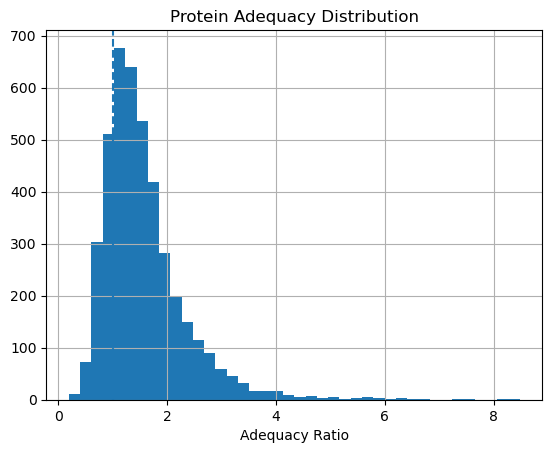

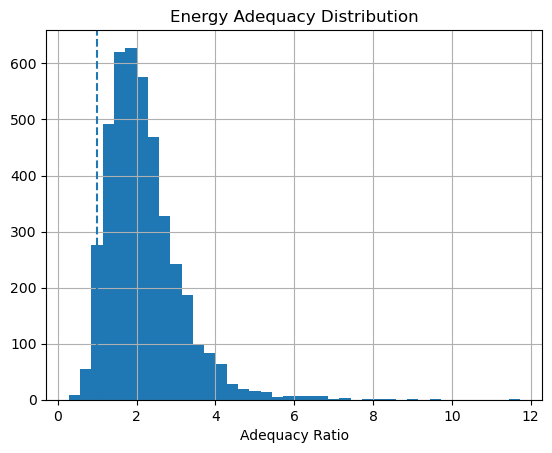

In [35]:
for nutrient in ['Protein', 'Energy']:
    adequacy.loc[nutrient].hist(bins=40)
    plt.axvline(1, linestyle='--')
    plt.title(f"{nutrient} Adequacy Distribution")
    plt.xlabel("Adequacy Ratio")
    plt.show()

While most households meet protein requirements, there is a significant left tail of households that fall below adequacy. This indicates inequality in access to protein-rich foods, rather than a universal shortage

Energy adequacy is generally high across households, with most consuming well above required calorie levels. This reinforces that calorie deficiency is not the primary issue; instead, the challenge lies in nutrient quality.

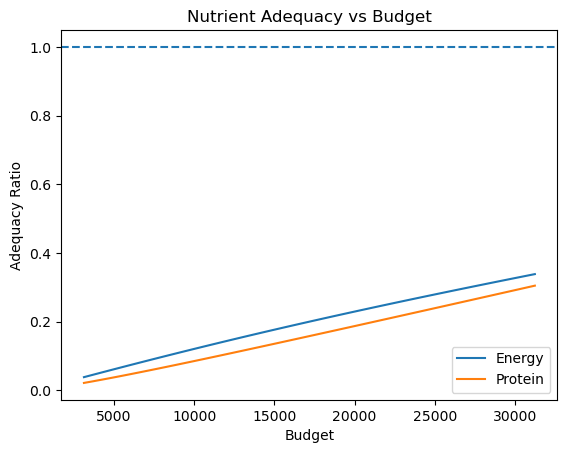

In [36]:
X = np.linspace(xref/5, xref*2, 50)

df = pd.DataFrame({
    x: nutrient_adequacy_ratio(x, pbar, dbar)[['Energy','Protein']]
    for x in X
}).T

df.plot()
plt.axhline(1, linestyle='--')
plt.title("Nutrient Adequacy vs Budget")
plt.xlabel("Budget")
plt.ylabel("Adequacy Ratio")
plt.show()

We observe that nutrient adequacy increases with household budget, indicating that income constraints play a role in nutritional outcomes. However, even at higher budget levels, households do not fully meet recommended protein and energy requirements. This suggests that increasing income alone may not fully solve nutritional deficiencies, and that food prices and dietary choices also play an important role.

### Summary

Our analysis shows that protein deficiency is the most significant nutritional challenge in Nigeria, affecting a substantial share of households, while calorie deficiency is relatively low. Distributional analysis reveals that while most households meet basic energy needs, a subset remains significantly protein deficient, indicating inequality in diet quality. Furthermore, nutrient adequacy improves with income, but does not reach recommended levels even at higher budgets. This suggests that both income constraints and food access or pricing issues contribute to persistent nutritional deficiencies.

### Cash Transfers

In [50]:
nutrient_adequacy_ratio(1.2 * xref, pbar, dbar)[UseNutrients]

Energy          0.216202
Niacin          0.077361
Protein         0.173900
Riboflavin      0.073067
Thiamin         0.053745
Vitamin B-12    0.197784
Vitamin B-6     0.129323
dtype: float64

### Food Subsidies

In [51]:
new_prices = pbar.copy()
new_prices[['Eggs','Brown beans']] *= 0.8

nutrient_adequacy_ratio(xref, new_prices, dbar)[UseNutrients]

Energy          0.184647
Niacin          0.063972
Protein         0.143537
Riboflavin      0.061067
Thiamin         0.045149
Vitamin B-12    0.160564
Vitamin B-6     0.107692
dtype: float64

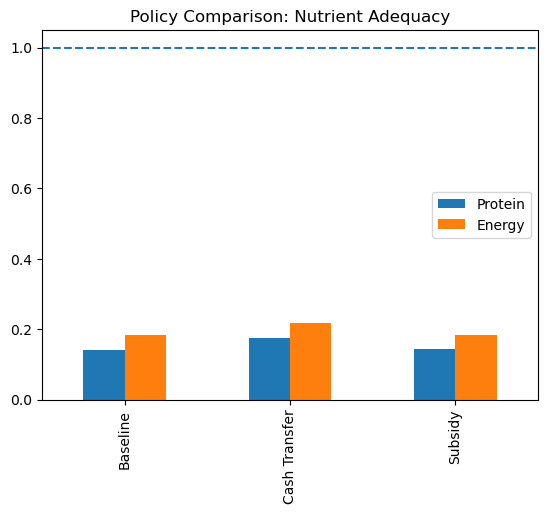

In [52]:
baseline = nutrient_adequacy_ratio(xref, pbar, dbar)
cash = nutrient_adequacy_ratio(1.2*xref, pbar, dbar)
subsidy = nutrient_adequacy_ratio(xref, new_prices, dbar)

df = pd.DataFrame({
    'Baseline': baseline[['Protein','Energy']],
    'Cash Transfer': cash[['Protein','Energy']],
    'Subsidy': subsidy[['Protein','Energy']]
}).T

df.plot(kind='bar')
plt.axhline(1, linestyle='--')
plt.title("Policy Comparison: Nutrient Adequacy")
plt.show()

Our policy simulations suggest that both cash transfers and food subsidies can improve nutritional outcomes, but neither is sufficient to fully eliminate deficiencies. Cash transfers increase overall consumption and have a broader effect on both energy and protein intake, while targeted subsidies improve access to specific nutrients but may be limited by substitution patterns and dietary preferences. Combined with earlier evidence that nutrient adequacy increases with income but remains below recommended levels, these results indicate that improving nutrition in Nigeria requires a multifaceted approach that addresses both income constraints and structural barriers such as food prices and access to nutrient-dense foods.